# AI4ALL Robotics Final Project Sketch
Students will combine all four modules. Mentors can use this notebook to guide the students in completing their final project & presentation.

| # | Module | Goal |
|:-:|--------|------|
| 1 | **Vision** | detect the colored object in an image |
| 2 | **Mapping** | convert pixel `(cx, cy)` → world `(x, y, z)` |
| 3 | **Motion Planning** | create a smooth trajectory for the robot arm |
| 4 | **Decision‑Making** | choose the correct bin via rule **or** ML |

At the end students should be able to run a live demo **and** present a 3‑minute slide deck.

In [ ]:
!pip install -q pybullet opencv-python matplotlib scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 MB 9.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import cv2, pybullet as p, pybullet_data, numpy as np, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from pathlib import Path
%matplotlib inline

## 0 · Global Settings
* Synthetic workspace: **1 m × 1 m** top‑down camera  
* Test image: 200 × 200 px red (or blue) circle  
* Robot: KUKA iiwa (7 joints, end‑effector link 6)


Text(0.5, 1.0, 'Test Image')

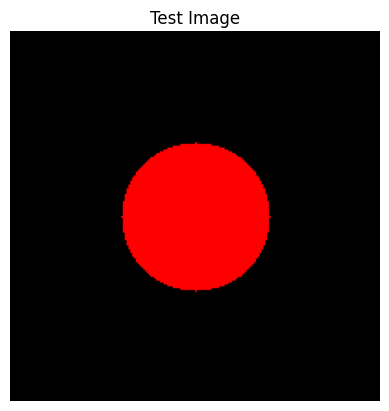

In [ ]:
# Synthetic Image Builder
IMG_W = IMG_H = 200
PLANE_M = 1.0       # metres

def make_circle_image(cx=100, cy=100, r=40, color='red'):
    img = np.zeros((IMG_H, IMG_W, 3), dtype=np.uint8)
    bgr = (0,0,255) if color=='red' else (255,0,0)
    cv2.circle(img, (cx,cy), r, bgr, -1)
    return img

test_img = make_circle_image()
plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.title('Test Image')


## 1 · Vision Module (`vision`)
Detect center of the red object.  
Replace the code between `# ---- START / END STUDENT CODE ----` with your Day 7 routine.


In [ ]:
# Vision
def vision(image):
    """
    Return (cx, cy) pixel center of red or blue object.
    Returns (None, None) if not found.
    """
    # ---- START STUDENT CODE ----
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Define range for red color
    lower_red1 = np.array([0, 100, 100])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([170, 100, 100])
    upper_red2 = np.array([180, 255, 255])
    mask_red = cv2.inRange(hsv, lower_red1, upper_red1) + cv2.inRange(hsv, lower_red2, upper_red2)

    # Define range for blue color
    lower_blue = np.array([100, 100, 100])
    upper_blue = np.array([140, 255, 255])
    mask_blue = cv2.inRange(hsv, lower_blue, upper_blue)

    # Combine masks
    mask = cv2.bitwise_or(mask_red, mask_blue)

    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return None, None
    c = max(cnts, key=cv2.contourArea)
    M = cv2.moments(c);
    if M["m00"] == 0: return None, None # Avoid division by zero
    cx = int(M["m10"]/M["m00"])
    cy = int(M["m01"]/M["m00"])
    # ---- END STUDENT CODE ----
    return cx, cy

In [ ]:
# Unit Test: Vision
cx, cy = vision(test_img)
assert cx is not None, "❌ Vision failed – tune HSV values!"
print(f"✅ Vision OK  – center @ ({cx},{cy}) px")


✅ Vision OK  – center @ (100,100) px


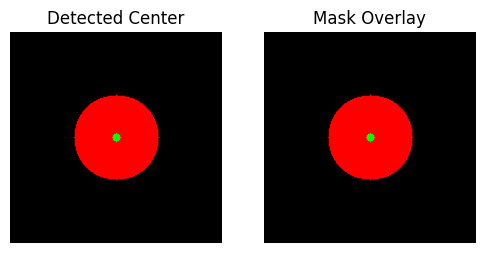

In [ ]:
# Sanity check: Vision Debug Overlay
vis = test_img.copy()
cv2.circle(vis, (cx, cy), 4, (0, 255, 0), -1)          # green dot at center
hsv = cv2.cvtColor(test_img, cv2.COLOR_BGR2HSV)
mask = cv2.inRange(hsv, np.array([0,100,100]), np.array([10,255,255]))
overlay = cv2.bitwise_and(vis, vis, mask=mask)         # keep red area
plt.figure(figsize=(6,3))
plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(vis,    cv2.COLOR_BGR2RGB)); plt.title("Detected Center"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); plt.title("Mask Overlay");  plt.axis('off')
plt.show()


What you see: left = original with green dot; right = masked region to confirm thresholding.


## 2 · Mapping Module (`pixel_to_world`)
Linear scale: pixel (0,0) → world (-0.5 m, -0.5 m); pixel (200,200) → (+0.5 m,+0.5 m).

In [ ]:
# Mapping Pixel to World
def pixel_to_world(cx, cy, img_shape=(IMG_H,IMG_W), plane=PLANE_M):
    """
    Map pixel to world XY (z=0).
    """
    h, w = img_shape
    x = (cx / w)*plane - plane/2
    y = (cy / h)*plane - plane/2
    return x, y, 0.0


In [ ]:
# Mapping Quick‑Check
wx, wy, wz = pixel_to_world(cx, cy)
print(f"Pixel ({cx},{cy}) → World ({wx:.2f},{wy:.2f},{wz}) m")


Pixel (100,100) → World (0.00,0.00,0.0) m


In [ ]:
# Sanity check: Pixel→World Grid Check
test_pts = [(0,0), (0, IMG_H), (IMG_W,0), (IMG_W, IMG_H), (IMG_W//2, IMG_H//2)]
for px,py in test_pts:
    wx,wy,_ = pixel_to_world(px,py)
    print(f"Pixel ({px:3},{py:3}) → World ({wx:+.3f},{wy:+.3f}) m")


Pixel (  0,  0) → World (-0.500,-0.500) m
Pixel (  0,200) → World (-0.500,+0.500) m
Pixel (200,  0) → World (+0.500,-0.500) m
Pixel (200,200) → World (+0.500,+0.500) m
Pixel (100,100) → World (+0.000,+0.000) m


You’ll see corner pixels mapping to (‑0.5 m, ‑0.5 m) … (+0.5 m, +0.5 m).


## 3 · Motion Planning (`plan_trajectory`)
Uses PyBullet IK to reach (x,y,z) and linearly interpolates in joint space.


In [ ]:
# Planning Trajectory
def plan_trajectory(start_angles, target_xyz, steps=12):
    cid = p.connect(p.DIRECT)
    p.setAdditionalSearchPath(pybullet_data.getDataPath())
    robot = p.loadURDF("kuka_iiwa/model.urdf", useFixedBase=True)
    ik = p.calculateInverseKinematics(robot, 6, target_xyz)
    traj = np.linspace(start_angles, ik[:7], steps)
    p.disconnect(cid)
    return traj


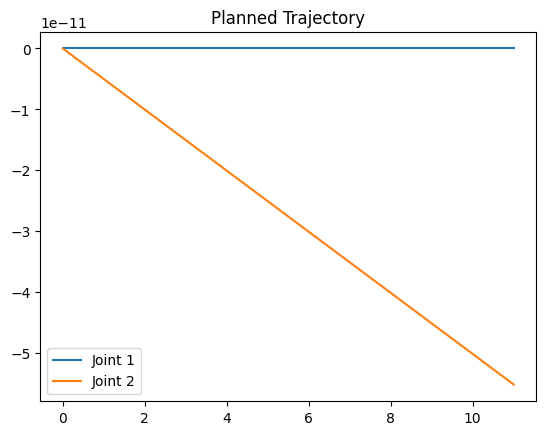

In [ ]:
# Trajectory Plot
start_q = np.zeros(7)
traj = plan_trajectory(start_q, [wx, wy, 0.15])
plt.plot(traj[:,0], label='Joint 1'); plt.plot(traj[:,1], label='Joint 2')
plt.title('Planned Trajectory'); plt.legend(); plt.show()


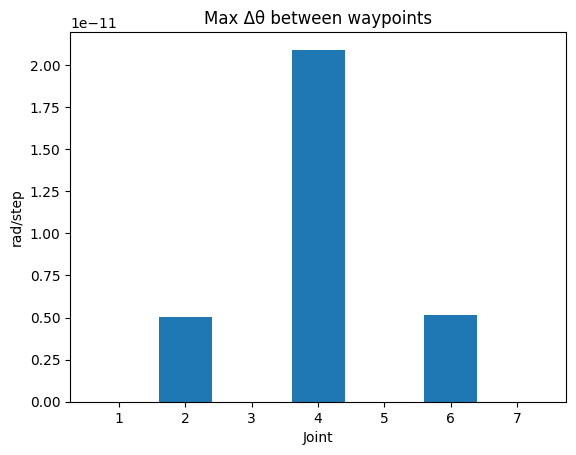

In [ ]:
# Sanity check: Joint‑Speed Bar‑Chart
speed = np.abs(np.diff(traj, axis=0))          # per‑step delta
max_speed = speed.max(axis=0)
plt.bar(range(1,8), max_speed)
plt.title('Max Δθ between waypoints'); plt.xlabel('Joint'); plt.ylabel('rad/step')
plt.show()


A high bar identifies joints that still have jerks.

## 4 · Decision‑Making (`decide_bin`)
Choose bin 0 vs 1 via rule **or** LogisticRegression (model supplied below).


In [ ]:
# (Optional) Train Logistic Regression
np.random.seed(42)
h  = np.concatenate([np.random.normal(5,1,30),  np.random.normal(120,4,30)])
ar = np.concatenate([np.random.normal(500,40,30), np.random.normal(300,60,30)])
y  = np.array([0]*30 + [1]*30)
clf = LogisticRegression().fit(np.column_stack([h,ar]), y)
print("LogReg training acc:", clf.score(np.column_stack([h,ar]), y))


LogReg training acc: 1.0


In [ ]:
# Decision-making
def decide_bin(features, model=None):
    """
    features = [hue_mean, area_px]
    If model provided → ML; else → rule.
    """
    if model:
        return int(model.predict([features])[0])
    hue, area = features
    return 0 if (hue < 30 and area > 400) else 1  # simple rule


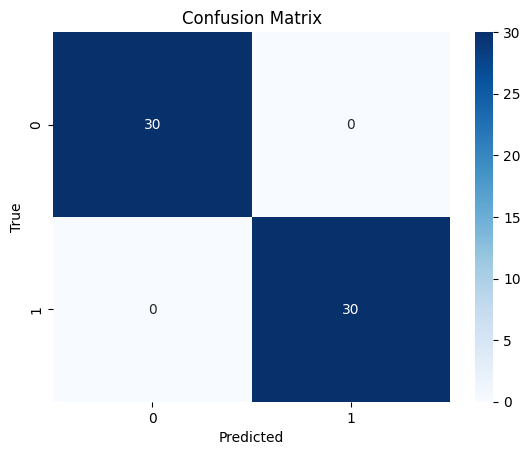

In [ ]:
# sanity check: Confusion Matrix Heatmap
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y, clf.predict(np.column_stack([h, ar])))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix")
plt.show()

A perfectly separated toy dataset should yield a diagonal matrix.

## 5 · Pipeline `run_pipeline(image, use_ml=False)`
Returns dict with pixel center, world coords, trajectory, and bin.


In [ ]:
# End-to-end pipeline
def run_pipeline(image, use_ml=False):
    cx, cy = vision(image)
    if cx is None: raise ValueError("Vision failed.")
    wx, wy, wz = pixel_to_world(cx, cy)
    traj = plan_trajectory(np.zeros(7), [wx, wy, wz+0.1])
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hue_mean = hsv[:,:,0].mean()
    area = np.sum(cv2.inRange(hsv, np.array([0,100,100]), np.array([10,255,255]))>0)
    bin_id = decide_bin([hue_mean, area], clf if use_ml else None)
    return {'pixel':(cx,cy), 'world':(wx,wy,wz), 'traj':traj, 'bin':bin_id}


In [ ]:
# End‑to‑End Dry Run
result = run_pipeline(test_img, use_ml=True)
result


{'pixel': (100, 100),
 'world': (0.0, 0.0, 0.0),
 'traj': array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00],
        [ 4.68893717e-23, -6.69050829e-12,  1.52814801e-22,
         -3.14648736e-11,  4.63362701e-23,  7.75858707e-12,
          0.00000000e+00],
        [ 9.37787434e-23, -1.33810166e-11,  3.05629602e-22,
         -6.29297472e-11,  9.26725402e-23,  1.55171741e-11,
          0.00000000e+00],
        [ 1.40668115e-22, -2.00715249e-11,  4.58444403e-22,
         -9.43946208e-11,  1.39008810e-22,  2.32757612e-11,
          0.00000000e+00],
        [ 1.87557487e-22, -2.67620332e-11,  6.11259205e-22,
         -1.25859494e-10,  1.85345080e-22,  3.10343483e-11,
          0.00000000e+00],
        [ 2.34446858e-22, -3.34525415e-11,  7.64074006e-22,
         -1.57324368e-10,  2.31681350e-22,  3.87929353e-11,
          0.00000000e+00],
        [ 2.81336230e-22, -4.01430497e-11,  9.16888807e-22,
 

### 🗣 Discussion #1  
*Does the chosen `bin` make sense?*  
Try changing `make_circle_image(color='blue')` and re‑run.


{'pixel': (100, 100), 'world': (0.0, 0.0, 0.0), 'traj': array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 4.68893717e-23, -6.69050829e-12,  1.52814801e-22,
        -3.14648736e-11,  4.63362701e-23,  7.75858707e-12,
         0.00000000e+00],
       [ 9.37787434e-23, -1.33810166e-11,  3.05629602e-22,
        -6.29297472e-11,  9.26725402e-23,  1.55171741e-11,
         0.00000000e+00],
       [ 1.40668115e-22, -2.00715249e-11,  4.58444403e-22,
        -9.43946208e-11,  1.39008810e-22,  2.32757612e-11,
         0.00000000e+00],
       [ 1.87557487e-22, -2.67620332e-11,  6.11259205e-22,
        -1.25859494e-10,  1.85345080e-22,  3.10343483e-11,
         0.00000000e+00],
       [ 2.34446858e-22, -3.34525415e-11,  7.64074006e-22,
        -1.57324368e-10,  2.31681350e-22,  3.87929353e-11,
         0.00000000e+00],
       [ 2.81336230e-22, -4.01430497e-11,  9.16888807e-22,
        -1.88789242e-

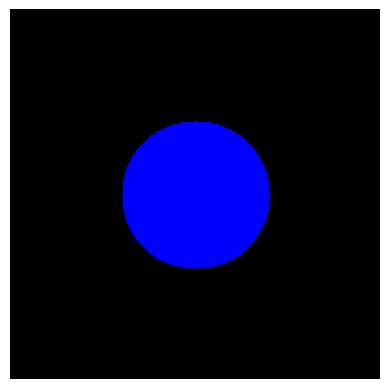

In [ ]:
# Blue Object Test
blue_img = make_circle_image(color='blue')
plt.imshow(cv2.cvtColor(blue_img, cv2.COLOR_BGR2RGB)); plt.axis('off')
print(run_pipeline(blue_img, use_ml=True))


## 6 · Headless Simulation Sanity Check
Executes trajectory in PyBullet (no GUI).


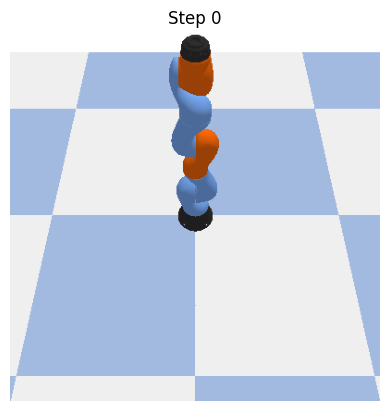

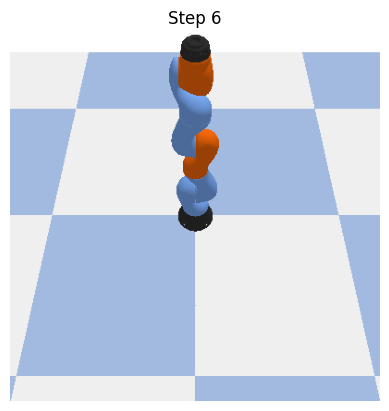

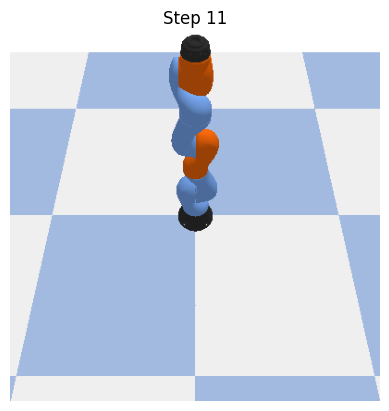

In [ ]:
# Headless Sim
cid = p.connect(p.DIRECT)
p.setAdditionalSearchPath(pybullet_data.getDataPath())
plane = p.loadURDF("plane.urdf")
bot   = p.loadURDF("kuka_iiwa/model.urdf", useFixedBase=True)
# camera config
view = p.computeViewMatrix(cameraEyePosition=[1,0,2],
                           cameraTargetPosition=[0,0,0],
                           cameraUpVector=[0,0,1])
proj = p.computeProjectionMatrixFOV(60, 1.0, 0.1, 3.0)

for step, q in enumerate(result['traj']):
    for j,val in enumerate(q):
      p.resetJointState(bot, j, val)
      p.stepSimulation()
    if step in (0, len(result['traj'])//2, len(result['traj'])-1):   # snap 3 frames
        _,_,rgb,_,_ = p.getCameraImage(400,400,view,proj)
        plt.imshow(np.reshape(rgb,(400,400,4))[:,:,:3]); plt.axis('off')
        plt.title(f'Step {step}'); plt.show()
p.disconnect(cid)


Students (and mentors) see three rendered frames even in headless mode, verifying the arm moves toward the target.

In [ ]:
import time, contextlib, io
buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    t0 = time.time()
    res = run_pipeline(test_img, use_ml=True)
    dt = time.time() - t0
print(buf.getvalue())            # raw internal prints if any
print(f"⏱ End‑to‑end runtime: {dt*1000:.1f} ms")



⏱ End‑to‑end runtime: 28.5 ms


Confirms the pipeline stays < 100 ms on Colab CPU.

**🔍 Debug Checklist**
- **Vision:** overlay mask on image → center green dot?  
- **Mapping:** verify `(cx,cy)` ↦ `(wx,wy)` for 3 locations.  
- **Trajectory:** plot each joint; watch for sudden jumps.  
- **Decision:** confusion matrix if you trained an ML model.


**🤝 Peer Code Review Prompts**
1. Can your partner reproduce identical mapping values?  
2. Swap ML vs rule in `decide_bin`; does pipeline still pass unit tests?  
3. Are your docstrings clear on input/output types?


**5‑Minute Presentation Outline**

1. **Goal & Story** — Why build an AI‑powered sorter?  
2. **System Diagram** — Vision → Mapping → Planning → Decision.  
3. **Live Demo** — Run `run_pipeline` with two test images.  
4. **Biggest Bug** — How you crushed it.  
5. **Key Take‑away** — Advice for next year’s cohort.


**✅ Submission Checklist**
- Notebook runs *top‑to‑bottom* without manual edits  
- All TODOs completed or commented clearly  
- Code pushed to Git repo with commit message `final_demo_<team>`  
- Slides (optional) shared with mentors
